In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
from transformers import pipeline
import torch
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for better aesthetics
sns.set(style='whitegrid')


In [2]:
# 1. Load the FER2013 CSV file
data = pd.read_csv(r'C:\Users\muham\PycharmProjects\pythonProject\fer2013.csv')

# Display the first few rows
data.head()


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [3]:
# Define emotion labels (lowercase for consistency)
emotion_labels = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

# Display the mapping
label_mapping = {i: label for i, label in enumerate(emotion_labels)}
label_mapping


{0: 'angry',
 1: 'disgust',
 2: 'fear',
 3: 'happy',
 4: 'sad',
 5: 'surprise',
 6: 'neutral'}

In [4]:
# 2. Split the data into training, validation, and test sets
train_data = data[data['Usage'] == 'Training']
val_data = data[data['Usage'] == 'PublicTest']
test_data = data[data['Usage'] == 'PrivateTest']

print(f"Training samples: {train_data.shape[0]}")
print(f"Validation samples: {val_data.shape[0]}")
print(f"Test samples: {test_data.shape[0]}")


Training samples: 28709
Validation samples: 3589
Test samples: 3589


In [5]:
# 4. Create a mapping from lowercase label to index
label_to_index = {label.lower(): idx for idx, label in enumerate(emotion_labels)}
label_to_index


{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'sad': 4,
 'surprise': 5,
 'neutral': 6}

In [6]:
# 5. Preprocessing function
def preprocess_data(df, target_size=(224, 224), num_images=None, random_state=42):
    """
    Preprocesses the FER2013 dataset.

    Parameters:
    - df (DataFrame): The dataframe containing the dataset.
    - target_size (tuple): Desired image size.
    - num_images (int): Number of images to preprocess. If None, preprocess all.
    - random_state (int): Seed for reproducibility.

    Returns:
    - faces (np.array): NumPy array of image data.
    - faces_pil (list): List of PIL Image objects.
    - labels (np.array): One-hot encoded labels.
    """
    pixels = df['pixels'].tolist()
    faces = []
    faces_pil = []
    labels = df['emotion'].tolist()

    # Shuffle and select a subset if num_images is specified
    if num_images is not None:
        np.random.seed(random_state)
        indices = np.random.choice(len(df), num_images, replace=False)
        pixels = [pixels[i] for i in indices]
        labels = [labels[i] for i in indices]

    for pixel_sequence in pixels:
        # Convert pixel string to 48x48 numpy array
        face = np.asarray(pixel_sequence.split(' '), dtype='float32').reshape(48, 48)
        # Ensure pixel values are in [0, 255]
        face = np.clip(face, 0, 255).astype('uint8')
        face = Image.fromarray(face).convert('RGB')  # Convert to RGB
        face_resized = face.resize(target_size)  # Resize to target size
        face_array = np.array(face_resized)

        faces.append(face_array)
        faces_pil.append(face_resized)

    faces = np.array(faces)
    labels = to_categorical(labels, num_classes=7)
    return faces, faces_pil, labels


In [7]:
# 6. Set the number of images to use for prediction
NUM_IMAGES = 50  # Adjust this number as needed

# 7. Apply preprocessing to the test set
x_test, x_test_pil, y_test = preprocess_data(test_data, num_images=NUM_IMAGES)

print(f'Test subset shape: {x_test.shape}, {y_test.shape}')


Test subset shape: (50, 224, 224, 3), (50, 7)


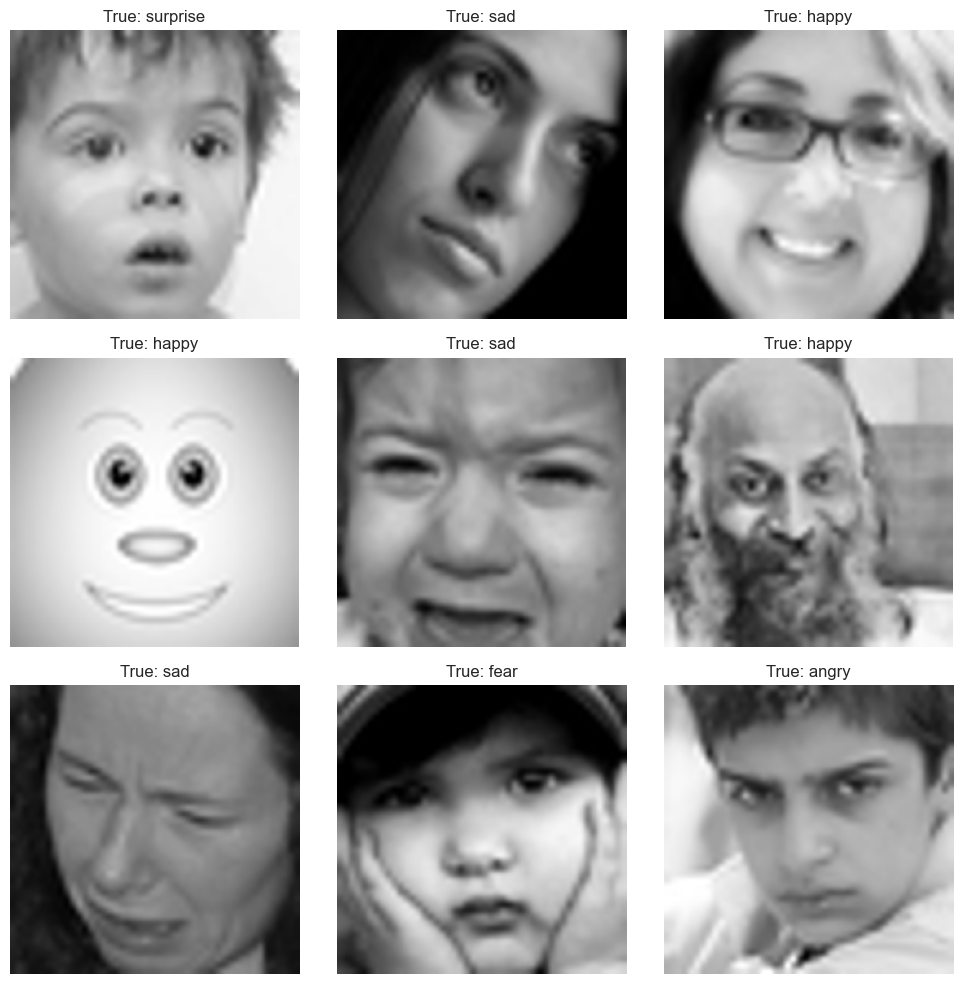

In [9]:
# Visualizing Sample Images
def display_sample_images(images, labels, label_mapping, num_samples=9):
    """
    Displays a grid of sample images with their corresponding labels.

    Parameters:
    - images (list): List of PIL Image objects.
    - labels (list or array): List or array of true class indices.
    - label_mapping (dict): Mapping from class indices to label names.
    - num_samples (int): Number of samples to display.
    """
    plt.figure(figsize=(10, 10))
    indices = np.random.choice(len(images), num_samples, replace=False)

    for i, idx in enumerate(indices):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[idx])
        plt.title(f"True: {label_mapping[np.argmax(y_test[idx])]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display 9 random sample images
display_sample_images(x_test_pil, y_test, label_mapping, num_samples=9)


In [8]:
# Check for GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Using device: {'GPU' if device == 0 else 'CPU'}")


Using device: CPU


In [10]:
# 8. Initialize Hugging Face pipelines for both models
# Model 1: trpakov/vit-face-expression
pipe_vit_face = pipeline(
    "image-classification",
    model="trpakov/vit-face-expression",
    device=device
)

# Model 2: motheecreator/vit-Facial-Expression-Recognition
pipe_mothee_vit = pipeline(
    "image-classification",
    model="motheecreator/vit-Facial-Expression-Recognition",
    device=device
)


Device set to use cpu
Device set to use cpu


In [11]:
# 9. Define function to get predictions
def get_predictions(pipeline, images_pil):
    """
    Makes predictions using the Hugging Face pipeline.

    Parameters:
    - pipeline: The Hugging Face image classification pipeline.
    - images_pil (list): List of PIL Image objects.

    Returns:
    - predictions (list): List of predicted labels.
    """
    predictions = []
    for img in tqdm(images_pil, desc="Predicting"):
        preds = pipeline(img)
        # preds is a list with a single dict
        predictions.append(preds[0]['label'])
    return predictions


In [12]:
# 10. Make predictions with both models
print("\nPredicting with trpakov/vit-face-expression...")
preds_vit_face = get_predictions(pipe_vit_face, x_test_pil)

print("\nPredicting with motheecreator/vit-Facial-Expression-Recognition...")
preds_mothee_vit = get_predictions(pipe_mothee_vit, x_test_pil)



Predicting with trpakov/vit-face-expression...


Predicting: 100%|██████████| 50/50 [00:11<00:00,  4.49it/s]



Predicting with motheecreator/vit-Facial-Expression-Recognition...


Predicting: 100%|██████████| 50/50 [00:10<00:00,  4.63it/s]


In [13]:
print("Predictions from trpakov/vit-face-expression:")
print(preds_vit_face)

print("\nPredictions from motheecreator/vit-Facial-Expression-Recognition:")
print(preds_mothee_vit)


Predictions from trpakov/vit-face-expression:
['sad', 'sad', 'surprise', 'sad', 'happy', 'fear', 'neutral', 'angry', 'angry', 'fear', 'sad', 'sad', 'disgust', 'sad', 'fear', 'happy', 'happy', 'fear', 'angry', 'sad', 'angry', 'happy', 'happy', 'neutral', 'fear', 'angry', 'neutral', 'fear', 'sad', 'neutral', 'neutral', 'angry', 'fear', 'happy', 'neutral', 'angry', 'fear', 'surprise', 'fear', 'angry', 'sad', 'surprise', 'neutral', 'surprise', 'angry', 'fear', 'surprise', 'sad', 'sad', 'neutral']

Predictions from motheecreator/vit-Facial-Expression-Recognition:
['anger', 'sad', 'surprise', 'sad', 'happy', 'sad', 'sad', 'fear', 'anger', 'fear', 'sad', 'neutral', 'fear', 'sad', 'fear', 'happy', 'neutral', 'fear', 'neutral', 'fear', 'anger', 'anger', 'happy', 'fear', 'sad', 'anger', 'neutral', 'surprise', 'sad', 'neutral', 'neutral', 'anger', 'fear', 'fear', 'neutral', 'neutral', 'fear', 'surprise', 'fear', 'anger', 'sad', 'surprise', 'surprise', 'surprise', 'anger', 'fear', 'surprise', 'sad

In [14]:
# 11. Prepare true labels
true_classes = np.argmax(y_test, axis=1)
true_classes


array([0, 4, 5, 4, 3, 4, 4, 0, 0, 2, 4, 6, 2, 4, 2, 3, 6, 2, 6, 2, 0, 0,
       3, 2, 4, 0, 6, 5, 4, 4, 6, 0, 2, 3, 6, 0, 2, 5, 0, 0, 4, 5, 2, 5,
       4, 2, 5, 4, 4, 4], dtype=int64)

In [15]:
# 12. Map predicted labels to indices (case-insensitive)
pred_indices_vit_face = [label_to_index.get(label.lower(), -1) for label in preds_vit_face]
pred_indices_mothee_vit = [label_to_index.get(label.lower(), -1) for label in preds_mothee_vit]

print("Predicted indices from trpakov/vit-face-expression:")
print(pred_indices_vit_face)

print("\nPredicted indices from motheecreator/vit-Facial-Expression-Recognition:")
print(pred_indices_mothee_vit)


Predicted indices from trpakov/vit-face-expression:
[4, 4, 5, 4, 3, 2, 6, 0, 0, 2, 4, 4, 1, 4, 2, 3, 3, 2, 0, 4, 0, 3, 3, 6, 2, 0, 6, 2, 4, 6, 6, 0, 2, 3, 6, 0, 2, 5, 2, 0, 4, 5, 6, 5, 0, 2, 5, 4, 4, 6]

Predicted indices from motheecreator/vit-Facial-Expression-Recognition:
[-1, 4, 5, 4, 3, 4, 4, 2, -1, 2, 4, 6, 2, 4, 2, 3, 6, 2, 6, 2, -1, -1, 3, 2, 4, -1, 6, 5, 4, 6, 6, -1, 2, 2, 6, 6, 2, 5, 2, -1, 4, 5, 5, 5, -1, 2, 5, 4, 4, 4]


In [16]:
# 13. Filter out any invalid predictions
valid_indices_vit_face = [i for i, idx in enumerate(pred_indices_vit_face) if idx != -1]
valid_indices_mothee_vit = [i for i, idx in enumerate(pred_indices_mothee_vit) if idx != -1]

# Check if there are any valid predictions
if not valid_indices_vit_face:
    print("\nWarning: No valid predictions for trpakov/vit-face-expression. Please check label mapping.")
if not valid_indices_mothee_vit:
    print("\nWarning: No valid predictions for motheecreator/vit-Facial-Expression-Recognition. Please check label mapping.")


In [17]:
# 14. Filter true and predicted labels
true_filtered_vit_face = true_classes[valid_indices_vit_face]
pred_filtered_vit_face = np.array(pred_indices_vit_face)[valid_indices_vit_face]

true_filtered_mothee_vit = true_classes[valid_indices_mothee_vit]
pred_filtered_mothee_vit = np.array(pred_indices_mothee_vit)[valid_indices_mothee_vit]


In [18]:
# 15. Define function to calculate metrics
def calculate_metrics(true, pred, model_name):
    """
    Calculates and prints evaluation metrics.

    Parameters:
    - true (np.array): True class indices.
    - pred (np.array): Predicted class indices.
    - model_name (str): Name of the model.
    """
    acc = accuracy_score(true, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(true, pred, average='weighted', zero_division=0)
    print(f"\n{model_name} Metrics:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(true, pred, target_names=emotion_labels, labels=range(len(emotion_labels)), zero_division=0))


In [19]:
# 16. Calculate metrics for both models
calculate_metrics(true_filtered_vit_face, pred_filtered_vit_face, "trpakov/vit-face-expression")
calculate_metrics(true_filtered_mothee_vit, pred_filtered_mothee_vit, "motheecreator/vit-Facial-Expression-Recognition")



trpakov/vit-face-expression Metrics:
Accuracy: 0.6600
Precision: 0.6975
Recall: 0.6600
F1-Score: 0.6711

Classification Report:
              precision    recall  f1-score   support

       angry       0.78      0.70      0.74        10
     disgust       0.00      0.00      0.00         0
        fear       0.60      0.60      0.60        10
       happy       0.67      1.00      0.80         4
         sad       0.73      0.57      0.64        14
    surprise       1.00      0.83      0.91         6
     neutral       0.38      0.50      0.43         6

    accuracy                           0.66        50
   macro avg       0.59      0.60      0.59        50
weighted avg       0.70      0.66      0.67        50


motheecreator/vit-Facial-Expression-Recognition Metrics:
Accuracy: 0.8571
Precision: 0.8129
Recall: 0.8571
F1-Score: 0.8279

Classification Report:
              precision    recall  f1-score   support

       angry       0.00      0.00      0.00         3
     disgust    

In [20]:
# 17. Define function to plot confusion matrix
def plot_confusion_matrix(true, pred, model_name):
    """
    Plots the confusion matrix for a given model.

    Parameters:
    - true (np.array): True class indices.
    - pred (np.array): Predicted class indices.
    - model_name (str): Name of the model.
    """
    cm = confusion_matrix(true, pred, labels=range(len(emotion_labels)))
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotion_labels,
                yticklabels=emotion_labels)
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


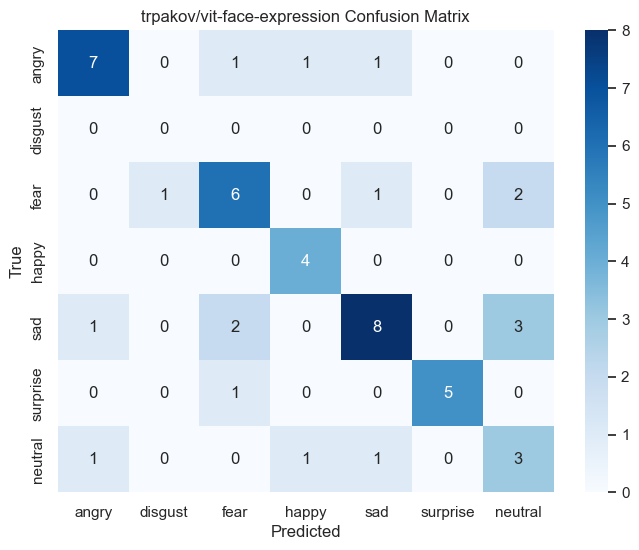

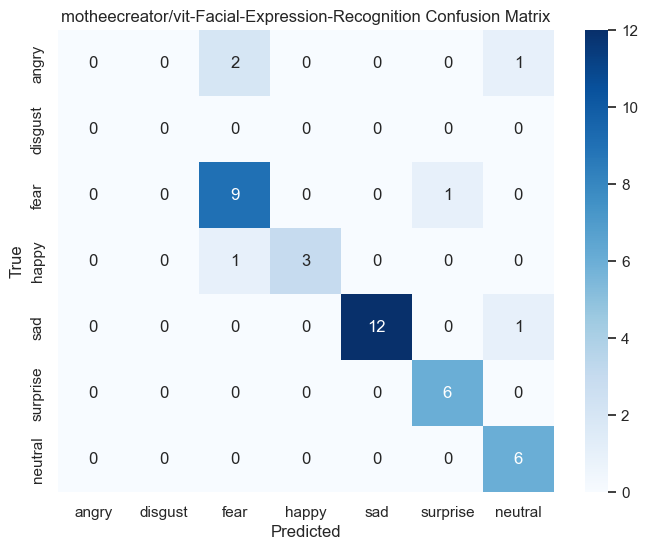

In [21]:
# 18. Plot confusion matrices for both models
if len(true_filtered_vit_face) > 0 and len(pred_filtered_vit_face) > 0:
    plot_confusion_matrix(true_filtered_vit_face, pred_filtered_vit_face, 'trpakov/vit-face-expression')

if len(true_filtered_mothee_vit) > 0 and len(pred_filtered_mothee_vit) > 0:
    plot_confusion_matrix(true_filtered_mothee_vit, pred_filtered_mothee_vit, 'motheecreator/vit-Facial-Expression-Recognition')


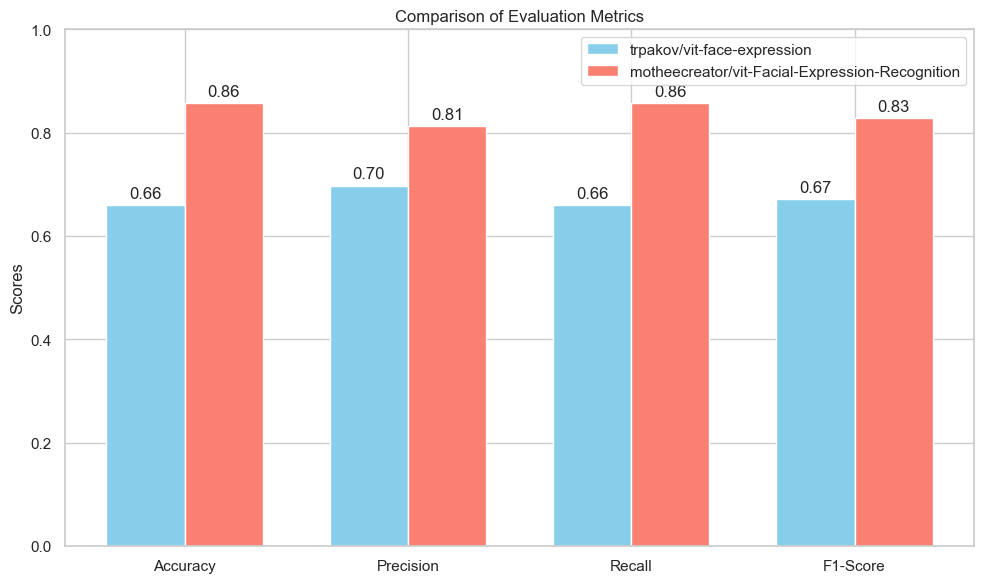

In [22]:
# 19. Comparative Metrics Visualization
def comparative_metrics(true_vit_face, pred_vit_face, true_mothee_vit, pred_mothee_vit, model1_name, model2_name):
    """
    Calculates and plots comparative evaluation metrics for two models.

    Parameters:
    - true_vit_face, pred_vit_face: True and predicted labels for model 1.
    - true_mothee_vit, pred_mothee_vit: True and predicted labels for model 2.
    - model1_name, model2_name: Names of the models.
    """
    # Calculate metrics for Model 1
    acc1 = accuracy_score(true_vit_face, pred_vit_face)
    precision1, recall1, f1_1, _ = precision_recall_fscore_support(true_vit_face, pred_vit_face, average='weighted', zero_division=0)

    # Calculate metrics for Model 2
    acc2 = accuracy_score(true_mothee_vit, pred_mothee_vit)
    precision2, recall2, f1_2, _ = precision_recall_fscore_support(true_mothee_vit, pred_mothee_vit, average='weighted', zero_division=0)

    # Prepare data for plotting
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    model1_scores = [acc1, precision1, recall1, f1_1]
    model2_scores = [acc2, precision2, recall2, f1_2]

    x = np.arange(len(metrics))  # label locations
    width = 0.35  # width of the bars

    fig, ax = plt.subplots(figsize=(10,6))
    rects1 = ax.bar(x - width/2, model1_scores, width, label=model1_name, color='skyblue')
    rects2 = ax.bar(x + width/2, model2_scores, width, label=model2_name, color='salmon')

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Scores')
    ax.set_title('Comparison of Evaluation Metrics')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1)
    ax.legend()

    # Attach a text label above each bar in rects, displaying its height.
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    plt.show()

# Call the comparative metrics function
comparative_metrics(true_filtered_vit_face, pred_filtered_vit_face, true_filtered_mothee_vit, pred_filtered_mothee_vit,
                    "trpakov/vit-face-expression", "motheecreator/vit-Facial-Expression-Recognition")


In [1]:
# test_opencv.py
import cv2

# Create a black image
img = cv2.imread(r"C:\Users\muham\OneDrive\Pictures\WhatsApp Image 2024-09-05 at 13.39.35_e3b86854-Photoroom.png")  # Replace with a valid image path

# Display the image
cv2.imshow('Test Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()
